# 05  — Part 1 - In-Sample / Out-of-Sample Validation
## Objective

The objective of this notebook is to evaluate whether the momentum strategy remains robust across different time periods.

We split the backtest into :

- In-sample period: 2012–2018
- Out-of-sample period: 2019–2025

The out-of-sample period is especially important because it tests the strategy on a later period that was not used for initial assessment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("../src")
from metrics import cagr, annualized_volatility, sharpe_ratio

## 1. Load Backtest Summary
We reuse the monthly backtest summary created previously.

It contains :
- strategy returns
- strategy equity
- FEZ benchmark returns
- FEZ benchmark equity
- selected tickers



## 2. Define In-Sample and Out-of-Sample Periods
The split is defined as:
- In-sample: 2012-01-01 to 2018-12-31
- Out-of-sample: 2019-01-01 to 2025-12-31

The in-sample period is used to observe the initial behavior of the strategy.
The out-of-sample period is used to check whether the strategy remains effective in a later and independent period.

In [2]:
backtest_summary = pd.read_csv("../data/backtest_summary.csv", index_col=0, parse_dates=True)
backtest_summary.head()


is_start = "2012-01-01"
is_end = "2018-12-31"
oos_start = "2019-01-01"
oos_end = "2025-12-31"

in_sample = backtest_summary.loc[is_start:is_end].copy()
out_sample = backtest_summary.loc[oos_start:oos_end].copy()
print("In-sample period:", in_sample.index.min(), "to", in_sample.index.max())
print("Out-of-sample period:", out_sample.index.min(), "to", out_sample.index.max())
print("In-sample shape:", in_sample.shape)
print("Out-of-sample shape:", out_sample.shape)

In-sample period: 2012-01-31 00:00:00 to 2018-12-31 00:00:00
Out-of-sample period: 2019-01-31 00:00:00 to 2025-12-31 00:00:00
In-sample shape: (84, 5)
Out-of-sample shape: (84, 5)


## 3. Rebase Equity Curves
To compare periods fairly, we rebase each equity curve to 100 at the beginning of its own period.
This makes the in-sample and out-of-sample performance easier to compare visually.


## 4. In-Sample Equity Curve
This plot compares the momentum strategy and FEZ benchmark during the in-sample period.


## 5. Out-of-Sample Equity Curve
This plot compares the momentum strategy and FEZ benchmark during the out-of-sample period.
The out-of-sample result is the most important validation step because it shows whether the strategy remains effective in a later period.

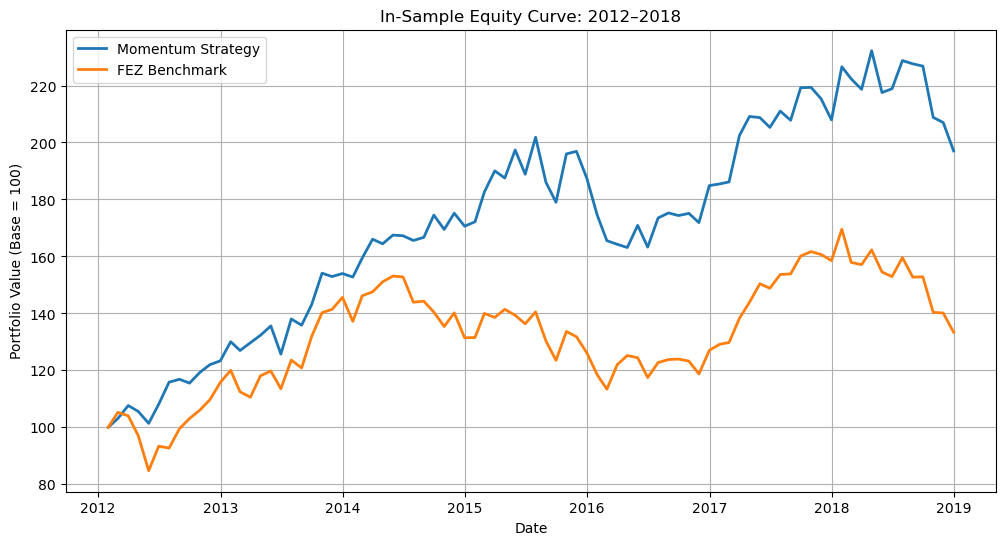

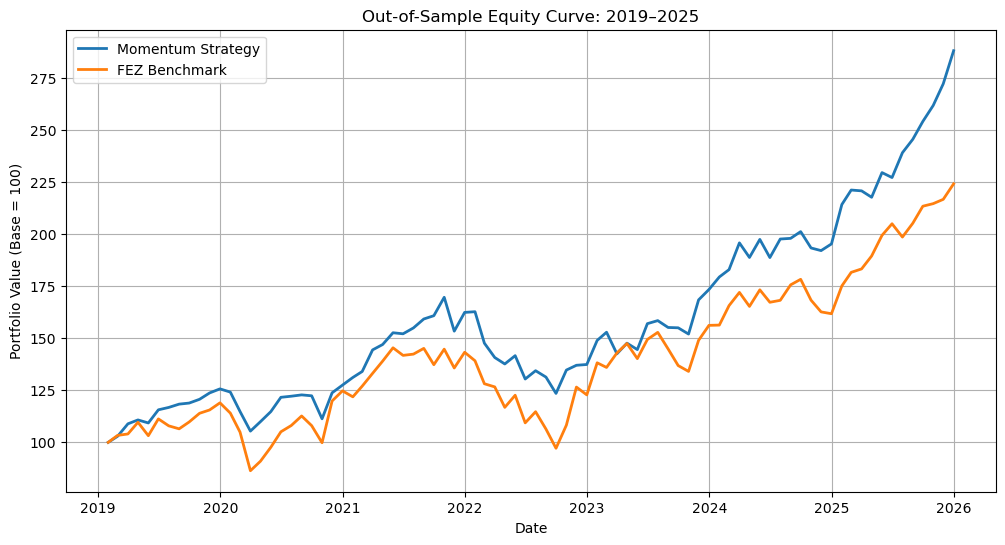

In [3]:
def rebase_equity(equity_series):
    equity_series = equity_series.dropna()
    return 100 * equity_series / equity_series.iloc[0]

in_sample_strategy_equity = rebase_equity(in_sample["Strategy Equity"])
in_sample_fez_equity = rebase_equity(in_sample["FEZ Equity"])
out_sample_strategy_equity = rebase_equity(out_sample["Strategy Equity"])
out_sample_fez_equity = rebase_equity(out_sample["FEZ Equity"])



plt.figure(figsize=(12, 6))
plt.plot(in_sample_strategy_equity, label="Momentum Strategy", linewidth=2)
plt.plot(in_sample_fez_equity, label="FEZ Benchmark", linewidth=2)
plt.title("In-Sample Equity Curve: 2012–2018")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.show()

print()

plt.figure(figsize=(12, 6))
plt.plot(out_sample_strategy_equity, label="Momentum Strategy", linewidth=2)
plt.plot(out_sample_fez_equity, label="FEZ Benchmark", linewidth=2)
plt.title("Out-of-Sample Equity Curve: 2019–2025")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.show()

## 6. Performance Metrics by Period

We compute CAGR, annualized volatility and Sharpe ratio separately for :

- in-sample momentum strategy
- in-sample FEZ benchmark
- out-of-sample momentum strategy
- out-of-sample FEZ benchmark

This allows us to compare the performance and risk profile across periods.

In [4]:
metrics_oos_table = pd.DataFrame({"IS Momentum Strategy": [cagr(in_sample_strategy_equity),annualized_volatility(in_sample["Strategy Return"]),sharpe_ratio(in_sample["Strategy Return"])],
                                  "IS FEZ Benchmark": [cagr(in_sample_fez_equity),annualized_volatility(in_sample["FEZ Return"]),sharpe_ratio(in_sample["FEZ Return"])],
                                  "OOS Momentum Strategy": [cagr(out_sample_strategy_equity),annualized_volatility(out_sample["Strategy Return"]),sharpe_ratio(out_sample["Strategy Return"])],
                                  "OOS FEZ Benchmark": [cagr(out_sample_fez_equity),annualized_volatility(out_sample["FEZ Return"]),sharpe_ratio(out_sample["FEZ Return"])]}, 
                                 index=["CAGR","Annualized Volatility","Sharpe Ratio"])

metrics_oos_table = metrics_oos_table.round(4)
metrics_oos_display = metrics_oos_table.copy().astype(object)
for col in metrics_oos_display.columns:
    metrics_oos_display.loc["CAGR", col] = f"{metrics_oos_table.loc['CAGR', col]:.2%}"
    metrics_oos_display.loc["Annualized Volatility", col] = f"{metrics_oos_table.loc['Annualized Volatility', col]:.2%}"
    metrics_oos_display.loc["Sharpe Ratio", col] = f"{metrics_oos_table.loc['Sharpe Ratio', col]:.2f}"
metrics_oos_display

,IS Momentum Strategy,IS FEZ Benchmark,OOS Momentum Strategy,OOS FEZ Benchmark
CAGR,10.30%,4.25%,16.52%,12.37%
Annualized Volatility,14.54%,16.33%,15.78%,20.97%
Sharpe Ratio,0.78,0.38,1.11,0.69


## 7. Interpretation

The in-sample and out-of-sample results suggest that the momentum strategy remains robust across different market periods.

During the in-sample period (2012–2018), the momentum strategy achieved a CAGR of 10.30%, compared to 4.25% for the FEZ benchmark.  
At the same time, the strategy exhibited lower annualized volatility (14.54% vs 16.33%) and a significantly higher Sharpe ratio (0.78 vs 0.38).

The out-of-sample period (2019–2025) is particularly important because it evaluates the strategy on a later and independent market environment.

During this period, the momentum strategy continued to outperform the benchmark, with:
- a CAGR of 16.52% versus 12.37% for FEZ
- lower volatility (15.78% vs 20.97%)
- a higher Sharpe ratio (1.11 vs 0.69)

These results suggest that the momentum effect remains persistent across time rather than being limited to a single market regime.

Overall, the strategy appears to generate:
- stronger returns than the benchmark
- lower risk
- superior risk-adjusted performance

The consistency between the in-sample and out-of-sample results strengthens the credibility and robustness of the momentum strategy.

## 8. Save Results

We save the in-sample and out-of-sample metrics table for reuse in the summary notebook.

In [5]:
metrics_oos_table.to_csv("../data/oos_metrics.csv")

print("File saved successfully:")
print("- ../data/oos_metrics.csv")

File saved successfully:
- ../data/oos_metrics.csv


## Conclusion Part 1

In this notebook, the momentum strategy was evaluated across two distinct and non-overlapping periods:

- In-sample: 2012–2018
- Out-of-sample: 2019–2025

The objective was to assess whether the momentum effect remained stable over time rather than being driven by a specific historical period.

The results show that the strategy outperformed the FEZ benchmark in both periods in terms of :
- annualized return (CAGR)
- volatility
- risk-adjusted performance (Sharpe ratio)

Importantly, the strategy also maintained strong results during the out-of-sample period, which increases the credibility of the momentum signal and reduces the risk of overfitting.

Overall, the analysis suggests that the momentum strategy exhibits a relatively robust performance profile across different market environments.

However, additional robustness tests and implementation constraints should still be considered before drawing definitive conclusions about real-world applicability.

# Part 2 - Parameter Robustness

## Objective
The second robustness test evaluates whether the momentum strategy is sensitive to parameter choices.
The initial strategy used :
- momentum window: 12-1
- selection threshold: top 30%

We now test alternative combinations :
- momentum windows: 6-1, 9-1, 12-1
- selection thresholds: top 20%, top 30%, top 40%

The objective is not to optimize the strategy, but to assess whether the momentum signal remains reasonably stable under different parameter assumptions.
A robust strategy should not rely on one isolated parameter configuration to generate acceptable performance.

## 9. Load Monthly Returns
For the parameter robustness test, we reuse the monthly return matrix.
The test is performed on gross returns to isolate the behavior of the momentum signal from transaction cost assumptions.


## 10. Momentum Window Definition
A momentum window such as 12-1 means that the most recent month is excluded from the signal.
Therefore :
- 6-1 uses the previous 5 monthly returns
- 9-1 uses the previous 8 monthly returns
- 12-1 uses the previous 11 monthly returns

This is implemented by shifting returns by one month before applying the rolling compounded return.

In [6]:
monthly_returns = pd.read_csv("../data/monthly_returns.csv", index_col=0, parse_dates=True)
print(monthly_returns.head())

def run_momentum_backtest(monthly_returns, momentum_window, top_quantile):
    """
    Run a long-only equal-weight momentum backtest.

    Parameters
    ----------
    monthly_returns : pd.DataFrame
        Monthly stock returns.
    momentum_window : int
        Momentum window label: 6, 9 or 12.
        A 12-1 strategy uses 11 monthly returns after excluding the most recent month.
    top_quantile : float
        Fraction of stocks selected each month, e.g. 0.30 for top 30%.

    Returns
    -------
    pd.Series
        Monthly gross strategy returns.
    """
    shifted_returns = monthly_returns.shift(1) #Exclude the most recent month from the signal
    rolling_window = momentum_window - 1 # Example: 12-1 uses 11 monthly returns
    
    momentum_score = (1 + shifted_returns).rolling(window=rolling_window).apply(np.prod,raw=True) - 1 # Compute compounded momentum score
    momentum_rank = momentum_score.rank(axis=1, ascending=False, method="min") # Rank stocks cross-sectionally each month

    n_stocks = monthly_returns.shape[1]
    top_n = int(np.floor(top_quantile * n_stocks))
    top_n = max(top_n, 1)
    selected = (momentum_rank <= top_n).astype(int)
    
    weights = selected.div(selected.sum(axis=1), axis=0)  
    invested_weights = weights.shift(1) # Shift weights by one month to avoid look-ahead bias

    # Compute strategy monthly returns
    strategy_returns = (invested_weights * monthly_returns).sum(axis=1, min_count=1)
    strategy_returns = strategy_returns.dropna()
    return strategy_returns

               AD.AS    AIR.PA    ALV.DE   ASML.AS    BAS.DE   BBVA.MC  \
Date                                                                     
2010-02-28 -0.010881  0.067254  0.054464 -0.020026  0.000364 -0.139639   
2010-03-31  0.096667 -0.017156  0.094693  0.183047  0.113482  0.060733   
2010-04-30  0.069112 -0.058073 -0.067974 -0.060846 -0.005432 -0.005148   
2010-05-31 -0.007752  0.161083 -0.011329 -0.051912 -0.020919 -0.143116   
2010-06-30 -0.007324  0.035604  0.005775 -0.029499  0.047608  0.010798   

              BNP.PA   ENEL.MI    ENI.MI    IBE.MC  ...   NESN.SW   NOVN.SW  \
Date                                                ...                       
2010-02-28  0.018792  0.020500 -0.021264 -0.043042  ...  0.058416  0.051030   
2010-03-31  0.070205  0.039548  0.048280  0.061041  ...  0.010290 -0.005490   
2010-04-30 -0.083187 -0.045290 -0.029361 -0.045418  ...  0.009140 -0.033380   
2010-05-31 -0.084067 -0.054396 -0.068506 -0.099833  ... -0.008514 -0.046304   
2010-06

## 11. Parameter Grid

We test three momentum windows and three selection thresholds.

This creates a 3 × 3 grid of strategy variants.


## 12. Grid Search

For each combination of momentum window and top quantile, we run the backtest and compute the Sharpe ratio.

The Sharpe ratio is used because it measures risk-adjusted performance.


In [7]:
momentum_windows = [6, 9, 12]
top_quantiles = [0.20, 0.30, 0.40]

results = []
for window in momentum_windows:
    for quantile in top_quantiles:
        strategy_returns = run_momentum_backtest(monthly_returns=monthly_returns,momentum_window=window,top_quantile=quantile)
        sharpe = sharpe_ratio(strategy_returns)
        results.append({"Momentum Window": f"{window}-1","Top Quantile": f"Top {int(quantile * 100)}%","Sharpe Ratio": sharpe})

robustness_results = pd.DataFrame(results)
robustness_results

,Momentum Window,Top Quantile,Sharpe Ratio
0,6-1,Top 20%,0.665650
1,6-1,Top 30%,0.826117
2,6-1,Top 40%,0.827982
3,9-1,Top 20%,0.897546
4,9-1,Top 30%,0.920280
5,9-1,Top 40%,0.927341
6,12-1,Top 20%,0.736451
7,12-1,Top 30%,0.877445
8,12-1,Top 40%,0.970058


## 13. Sharpe Ratio Matrix
We reshape the results into a matrix format.
Rows represent momentum windows.  
Columns represent portfolio selection thresholds.


## 14. Sharpe Ratio Heatmap
The heatmap shows how the Sharpe ratio changes across parameter choices.
A robust strategy should not depend on a single isolated parameter combination.
If several combinations produce acceptable Sharpe ratios, the strategy is more credible.

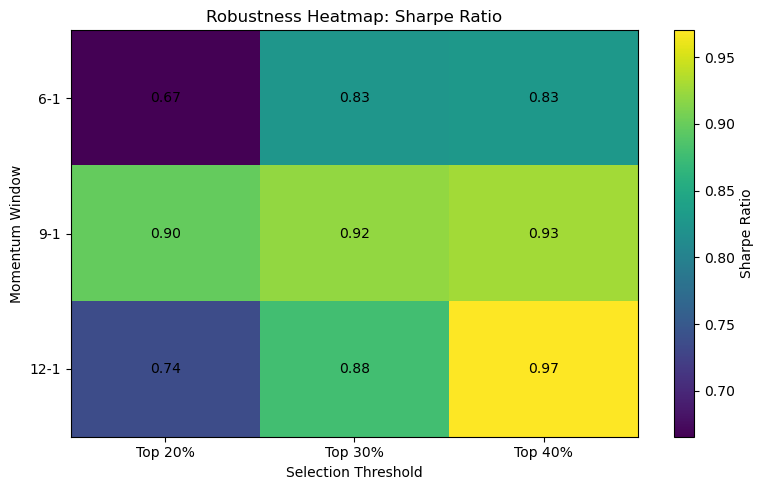

In [8]:
sharpe_matrix = robustness_results.pivot(index="Momentum Window",columns="Top Quantile",values="Sharpe Ratio")
sharpe_matrix = sharpe_matrix.loc[["6-1", "9-1", "12-1"],["Top 20%", "Top 30%", "Top 40%"]]
sharpe_matrix.round(3)


plt.figure(figsize=(8, 5))
plt.imshow(sharpe_matrix, aspect="auto")
plt.colorbar(label="Sharpe Ratio")
plt.xticks(ticks=np.arange(len(sharpe_matrix.columns)),labels=sharpe_matrix.columns)
plt.yticks(ticks=np.arange(len(sharpe_matrix.index)),labels=sharpe_matrix.index)
plt.title("Robustness Heatmap: Sharpe Ratio")
plt.xlabel("Selection Threshold")
plt.ylabel("Momentum Window")

for i in range(sharpe_matrix.shape[0]):
    for j in range(sharpe_matrix.shape[1]):
        value = sharpe_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

## 15. Save Robustness Results

We save the robustness grid results for reuse in the final summary notebook.

In [9]:
robustness_results.to_csv("../data/robustness_grid.csv", index=False)

print("File saved successfully:")
print("- ../data/robustness_grid.csv")

File saved successfully:
- ../data/robustness_grid.csv


## 16. Interpretation

The robustness heatmap shows whether the momentum strategy remains effective across different parameter choices.

If high Sharpe ratios are observed across several combinations, the strategy can be considered relatively robust.

If only one specific combination performs well while the others perform poorly, the strategy may be fragile and overly dependent on parameter selection.

The goal is not necessarily to find the single best parameter combination, but to assess whether the momentum effect is persistent across reasonable variations of the strategy.

## 17. Best / Base / Worst Strategy Comparison

The Sharpe ratio heatmap provides a synthetic view of parameter robustness.

To complement this analysis, we compare three representative equity curves:

- the base strategy: 12-1 momentum with top 30% selection
- the best parameter combination according to Sharpe ratio
- the worst parameter combination according to Sharpe ratio

This approach is more informative and readable than plotting all nine strategies simultaneously.

It allows us to evaluate whether the base strategy remains close to the strongest parameter configuration or whether performance depends excessively on one isolated setup.

Best combination:
Momentum Window        12-1
Top Quantile        Top 40%
Sharpe Ratio       0.970058
Name: 8, dtype: object

Worst combination:
Momentum Window        6-1
Top Quantile       Top 20%
Sharpe Ratio       0.66565
Name: 0, dtype: object


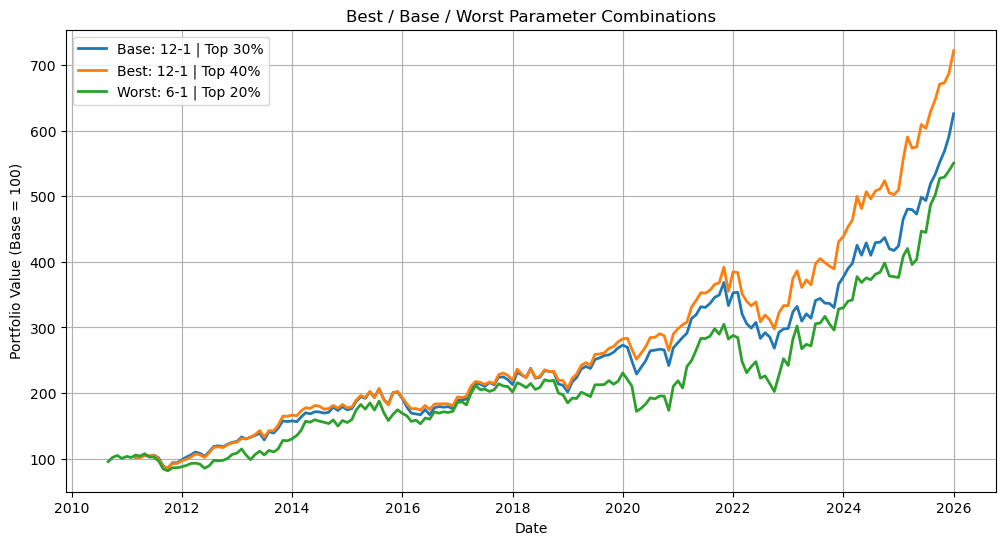

In [10]:
# Identify best and worst parameter combinations
best_row = robustness_results.loc[robustness_results["Sharpe Ratio"].idxmax()]
worst_row = robustness_results.loc[robustness_results["Sharpe Ratio"].idxmin()]
print("Best combination:")
print(best_row)
print("\nWorst combination:")
print(worst_row)


# Function to extract parameters from the robustness table
def parse_params(row):
    window = int(row["Momentum Window"].split("-")[0])
    quantile = (int(row["Top Quantile"].replace("Top ", "").replace("%", "")) / 100)
    return window, quantile


# Base strategy parameters
base_window = 12
base_quantile = 0.30

# Extract best and worst parameters
best_window, best_quantile = parse_params(best_row)
worst_window, worst_quantile = parse_params(worst_row)

# Run backtests
base_returns = run_momentum_backtest(monthly_returns,base_window,base_quantile)
best_returns = run_momentum_backtest(monthly_returns,best_window,best_quantile)
worst_returns = run_momentum_backtest(monthly_returns,worst_window,worst_quantile)

# Compute equity curves
base_equity = 100 * (1 + base_returns).cumprod()
best_equity = 100 * (1 + best_returns).cumprod()
worst_equity = 100 * (1 + worst_returns).cumprod()


# Plot equity curves
plt.figure(figsize=(12, 6))
plt.plot(base_equity,label="Base: 12-1 | Top 30%",linewidth=2)
plt.plot(best_equity,label=f"Best: {best_row['Momentum Window']} | {best_row['Top Quantile']}",linewidth=2)
plt.plot(worst_equity,label=f"Worst: {worst_row['Momentum Window']} | {worst_row['Top Quantile']}",linewidth=2)
plt.title("Best / Base / Worst Parameter Combinations")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.show()

## 18. Interpretation

This chart compares the base strategy with the best and worst parameter combinations identified in the robustness analysis.

The objective is not necessarily to maximize performance, but to evaluate whether the initial parameter choice remains reasonable compared to alternative configurations.

If the base strategy remains close to the best-performing configuration and clearly above the weakest one, it suggests that the original 12-1 / top 30% setup is not an isolated lucky result.

This visual analysis complements the Sharpe ratio heatmap by showing the full performance dynamics over time rather than only a final summary metric.

Overall, the strategy appears relatively stable across different parameter choices, which strengthens the credibility of the momentum signal.

## Conclusion Part 
This section tested the robustness of the momentum strategy across different parameter choices.
We varied :
- the momentum window: 6-1, 9-1, 12-1
- the portfolio selection threshold: top 20%, top 30%, top 40%

The Sharpe ratio heatmap and the comparison of the best, base and worst parameter combinations provide a broader view of the strategy behavior under different assumptions.

A credible strategy should not only perform well historically, but should also remain reasonably stable across different parameter choices.

If strong performance only appears for one isolated configuration, the strategy may be fragile and overly dependent on parameter tuning.

In this case, the results suggest that the momentum strategy remains relatively consistent across several reasonable parameter combinations, which strengthens the credibility and robustness of the momentum signal.